# Feature Selection by Mutual Information

## 4FGL Blazar Catalog (bll vs fsrq)

**Rule:** rank all 16 features by mutual information with the class label, then keep the top N features. 


In [1]:
import warnings
warnings.filterwarnings("ignore")

import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_selection import mutual_info_classif
from sklearn.model_selection import RepeatedStratifiedKFold, cross_val_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

np.random.seed(1234)
os.makedirs("./EDA", exist_ok=True)

## 1. Load

In [2]:
df = pd.read_csv("blazar_catalog_v35_features.csv")
df["CLASS1"] = df["CLASS1"].str.lower()

ID_COLS  = ["Source_Name", "ASSOC_FGL", "ASSOC1", "CLASS1"]
FEATURES = [c for c in df.columns if c not in ID_COLS]
# heavily-skewed / flux-like columns are put on a log scale (see note below)
LOG_COLS = ['PLEC_Flux_Density', 'LP_Flux_Density', 'PL_Flux_Density', 'Energy_Flux100',
            'Flux1000', 'Pivot_Energy', 'Npred', 'Variability_Index', 'Signif_Avg']

df_labeled = df[df["CLASS1"].isin(['bll', 'fsrq'])].copy()
df_bcu     = df[df["CLASS1"] == 'bcu'].copy()
for col in df_labeled.select_dtypes(include=np.number).columns:
    df_labeled[col] = df_labeled[col].fillna(df_labeled[col].median())

X_df = df_labeled[FEATURES].copy()
for c in LOG_COLS:
    X_df[c] = np.log10(X_df[c].clip(lower=1e-30))

X = X_df.values
y = (df_labeled["CLASS1"] == 'fsrq').astype(int).values
columns = FEATURES

print(f"bll {int((y==0).sum())} | fsrq {int((y==1).sum())} | bcu {len(df_bcu)} | features {len(FEATURES)}")
print(f"majority-class baseline accuracy = {max(y.mean(), 1-y.mean()):.4f}")

bll 1490 | fsrq 820 | bcu 1623 | features 16
majority-class baseline accuracy = 0.6450


Fermi fluxes are reported in cgs (~1e-13). sklearn's tree splitter treats a feature as constant
if all its values are closer together than `FEATURE_THRESHOLD = 1e-7`, so the flux columns would be
invisible to the Decision Tree and Random Forest while XGBoost still used them. The log scale fixes
that and is standard for fluxes anyway.

## 2. Correlation between features

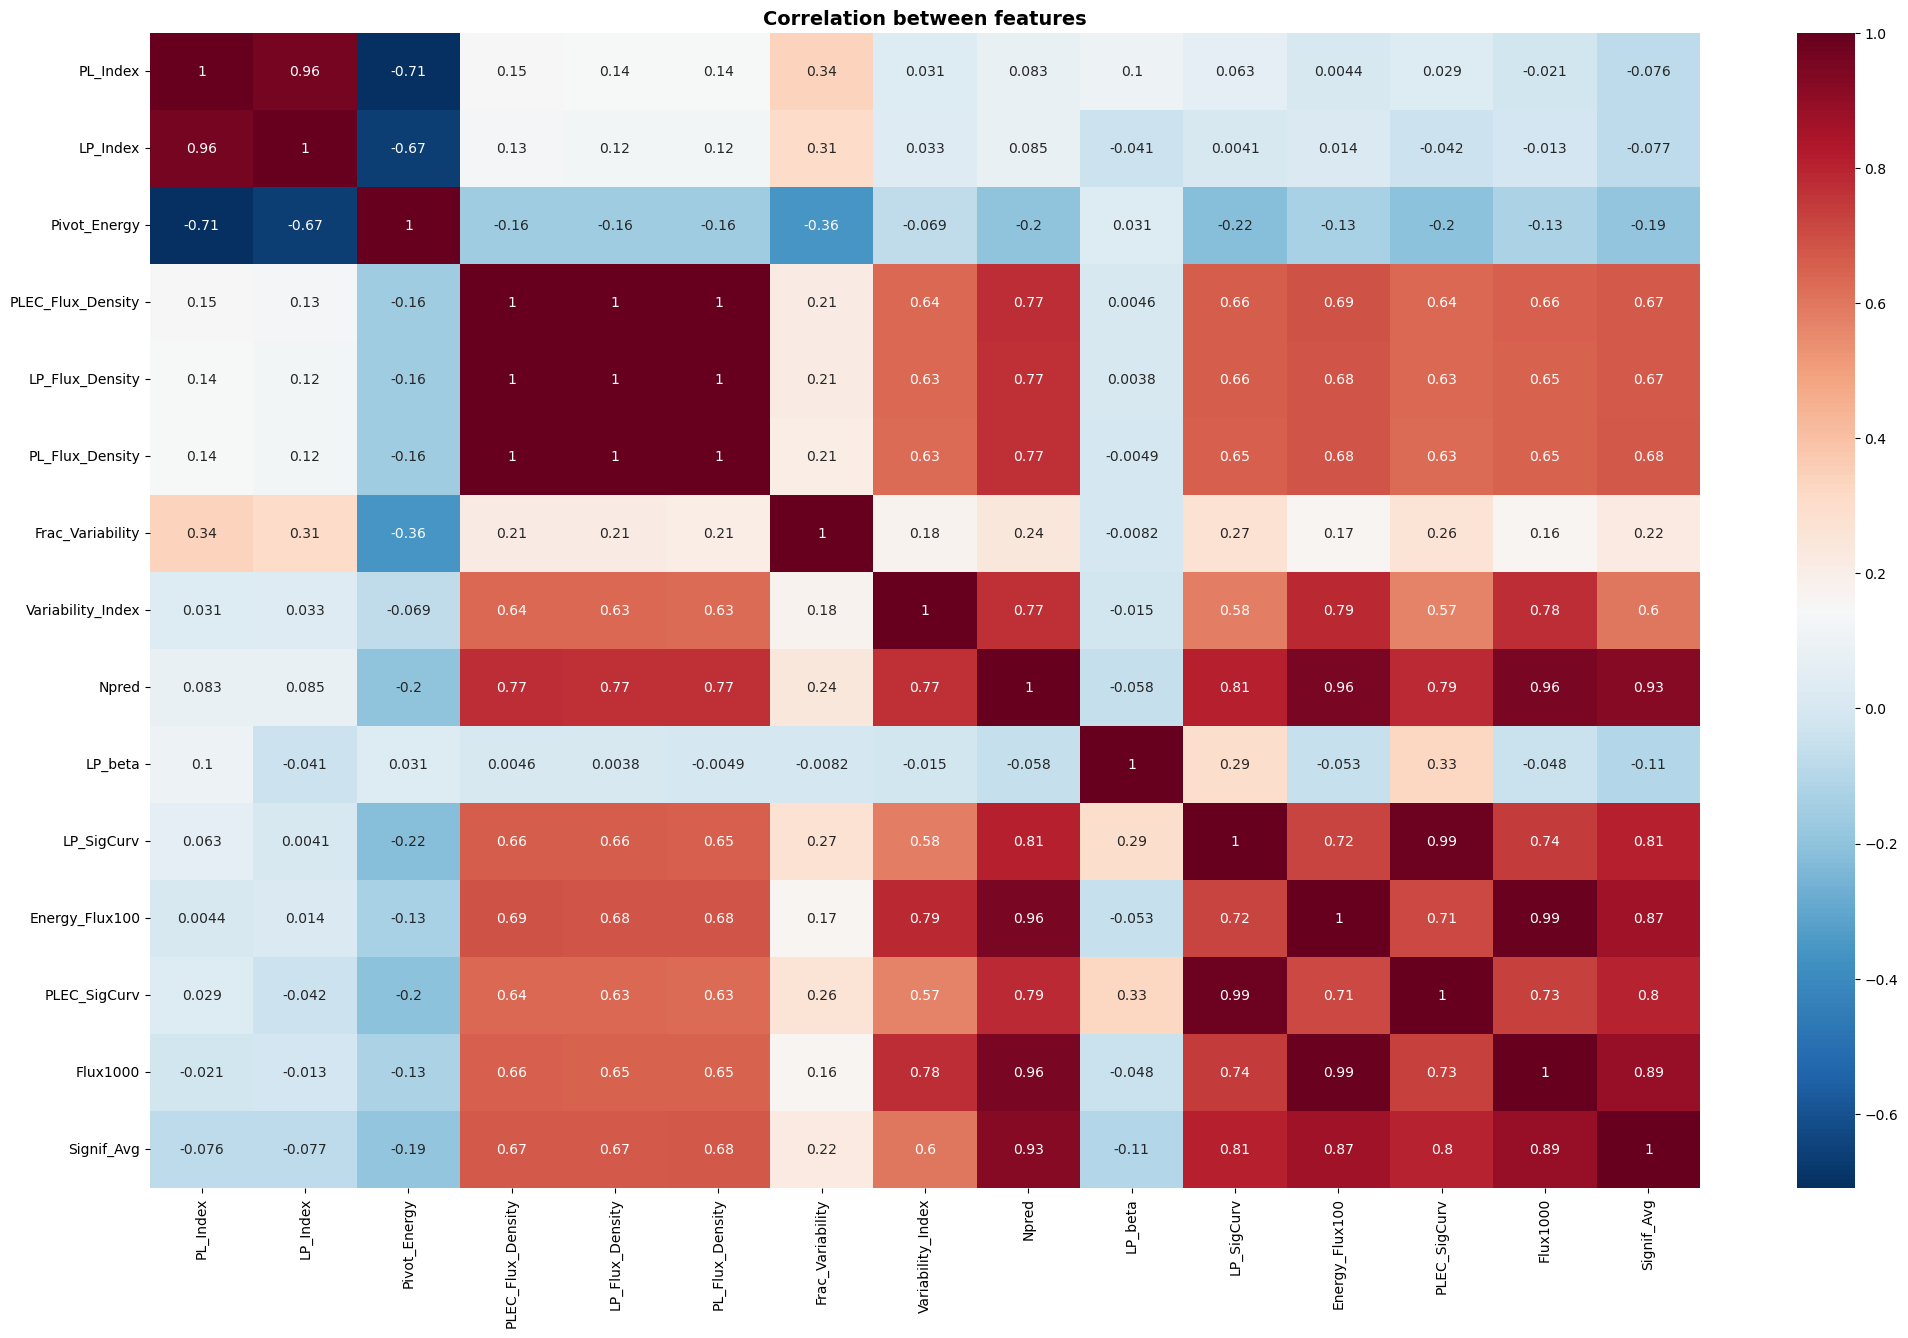

In [3]:
# Pearson correlation between features
cm = df[columns[:-1]].corr() # To avoid class labels; ‘kendall’, ‘spearman’

plt.figure(figsize=(25,15))
sns.heatmap(cm, cmap='RdBu_r', annot=True)
plt.title("Correlation between features", fontsize=14, weight='bold')
plt.savefig("./EDA/magic_correlation_features_.png")
plt.show()


## 3. Mutual information

              Feature  Mutual_Information
0            PL_Index            0.334202
1            LP_Index            0.314071
2        Pivot_Energy            0.299840
3   PLEC_Flux_Density            0.213009
4     LP_Flux_Density            0.203616
5     PL_Flux_Density            0.199599
6    Frac_Variability            0.144205
7   Variability_Index            0.103517
8               Npred            0.088187
9      Energy_Flux100            0.052219
10            LP_beta            0.033483
11         LP_SigCurv            0.019282
12       PLEC_SigCurv            0.018428
13           Flux1000            0.012048
14         Signif_Avg            0.007029
15     PLEC_Exp_Index            0.000000




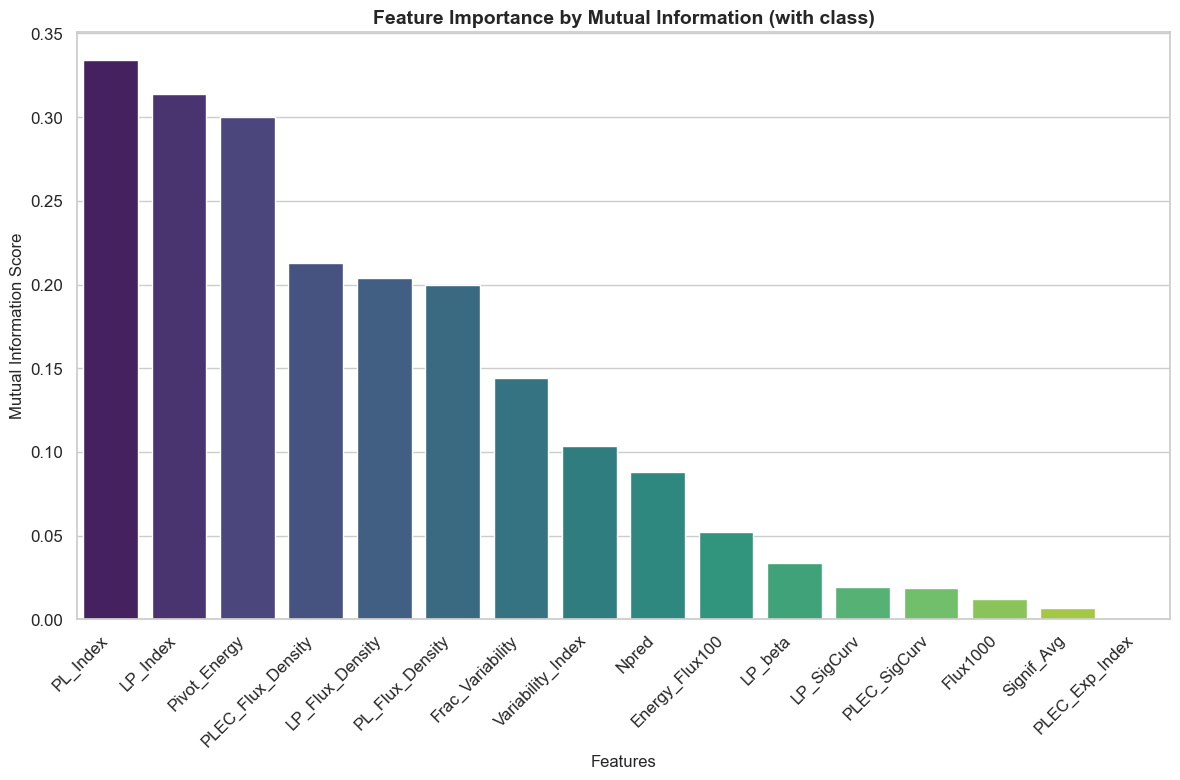

In [5]:
# Compute Mutual Information
mi_scores = mutual_info_classif(X, y, random_state=42)

# Create DataFrame
mi_df = pd.DataFrame({
    "Feature": columns,
    "Mutual_Information": mi_scores
}).sort_values(by="Mutual_Information", ascending=False).reset_index(drop=True)
print(mi_df)
print('\n')

# Plot
plt.figure(figsize=(12, 8))
sns.set(style="whitegrid", font_scale=1.1)

sns.barplot(
    x="Feature",
    y="Mutual_Information",
    data=mi_df,
    hue="Feature",
    palette="viridis",
    legend=False
)

plt.title("Feature Importance by Mutual Information (with class)", fontsize=14, weight='bold')
plt.xlabel("Features", fontsize=12)
plt.ylabel("Mutual Information Score", fontsize=12)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("./EDA/4FGL_MIscores_features_.png", dpi=150)
plt.show()

We selected `PL_Index`, `Pivot_Energy`, `Frac_Variability`, `Variability_Index`, and `LP_beta` because they provide a compact, relatively non-redundant set of physically meaningful features. They capture complementary information about the blazar spectrum, spectral curvature, characteristic energy, and variability, while avoiding highly correlated flux-related features that add little independent information.
